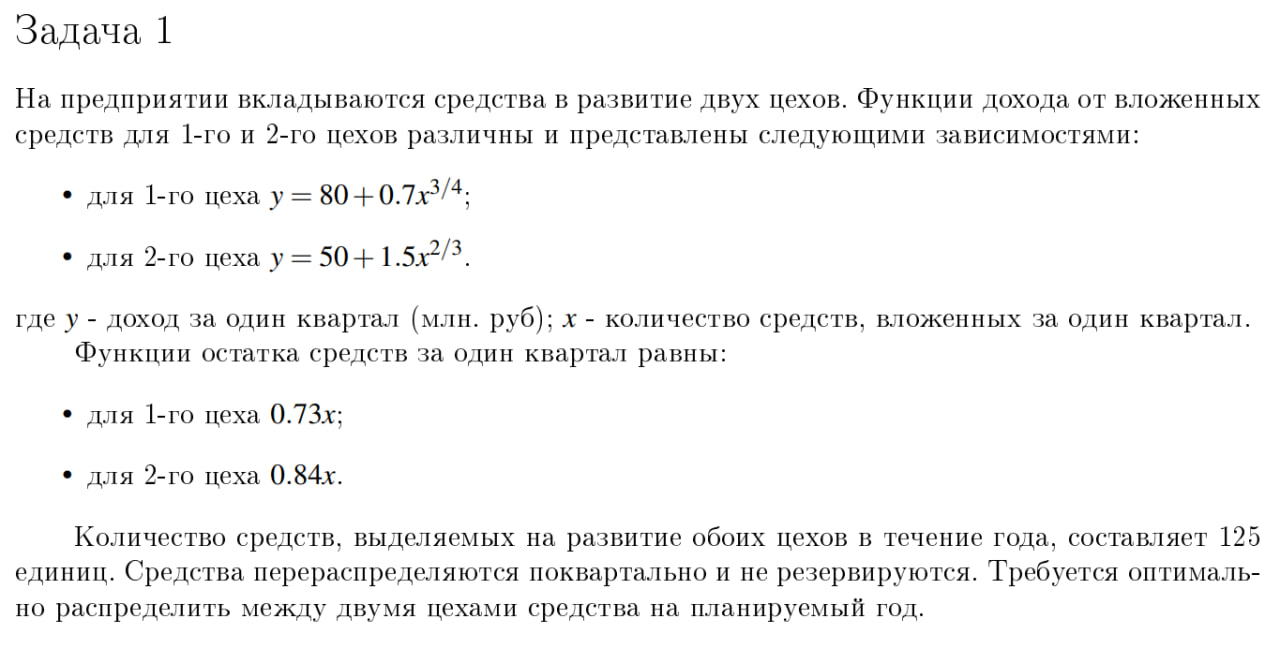

Формализация по Беллману
Этапами являются 4 квартала, в течение которых происходят вложения.
Состояние - это средства St в начале t квартала.
Управление. Пусть Xt - это средства, вложенные в 1 цех в t квартале. Ограничение на Xt: 0 <= Xt <= St.
Тогда (St-Xt) - средства, вложенные в 2 цех в t квартале.
Выигрыш. g(St; t) = (80 + 0.7x^(3/4)) + (50 + 1.5(St-Xt)^(2/3))
Переход. S(t+1) = 0.73xt + 0.84(St-Xt)
Функция Беллмана Wt(t, St) = max {g(St, Xt) + W(t+1)(t+1, S(t+1))} при этом Xt <= St.
При этом W5(5, S) = 0, потому что в конце нет инвестиций, требуется максимизация g.

In [1]:
from functools import lru_cache
import math

choice = {}

@lru_cache(None)
def W(t, S):
    if t == 5:
        return 0
    
    best = -float('inf')
    bestX = None
    for x in range(S + 1):
        x1 = x
        x2 = S - x
        g = (80 + 0.7 * (x1 ** (3/4))) + (50 + 1.5 * (x2 ** (2/3)))
        S_next = int(round(0.73 * x1 + 0.84 * x2))
        val = g + W(t + 1, S_next)
        if val > best:
            best=val
            bestX = x
    choice[(t, S)] = bestX
    return best
print(f"Максимальный доход = {round(W(1,125))}")
S = 125
for t in range(1, 5):
    x1 = choice[(t, S)]
    x2 = S - x1
    print(f"Квартал {t}: Цех1 = {x1}, Цех2 = {x2}, Доход за {t} квартал = {round((80 + 0.7 * (x1 ** (3/4))) + (50 + 1.5 * (x2 ** (2/3))))}")
    S = int(round(0.73 * x1 + 0.84 * x2))

Максимальный доход = 653
Квартал 1: Цех1 = 13, Цех2 = 112, Доход за 1 квартал = 170
Квартал 2: Цех1 = 16, Цех2 = 88, Доход за 2 квартал = 165
Квартал 3: Цех1 = 15, Цех2 = 71, Доход за 3 квартал = 161
Квартал 4: Цех1 = 16, Цех2 = 55, Доход за 4 квартал = 157
